# Getting Skagit Data

In [1]:
import geopandas as gpd
import rioxarray
import numpy as np
import csv

import xarray as xr
import matplotlib.pyplot as plt
from shapely.geometry import mapping
from rasterio.mask import mask

In [2]:
# create UA SWE dataset
path_ua = '../Dataset/UA_Data/'
files_ua = path_ua + '4km_SWE_Depth*.nc'
ds_ua = xr.open_mfdataset(files_ua, engine="netcdf4", data_vars='all')

In [3]:
# clip data
skagit_boundary = gpd.read_file('../Dataset/ShapeFiles/SkagitBoundary.json')

poly = skagit_boundary.geometry.to_list()
ua_skagit_clipped = ds_ua.SWE.rio.set_spatial_dims(x_dim='lon', y_dim='lat', inplace=True)
ua_skagit_clipped = ua_skagit_clipped.rio.write_crs("epsg:4326", inplace=True)
ua_skagit_clipped = ua_skagit_clipped.rio.clip(poly, crs="epsg:4326")

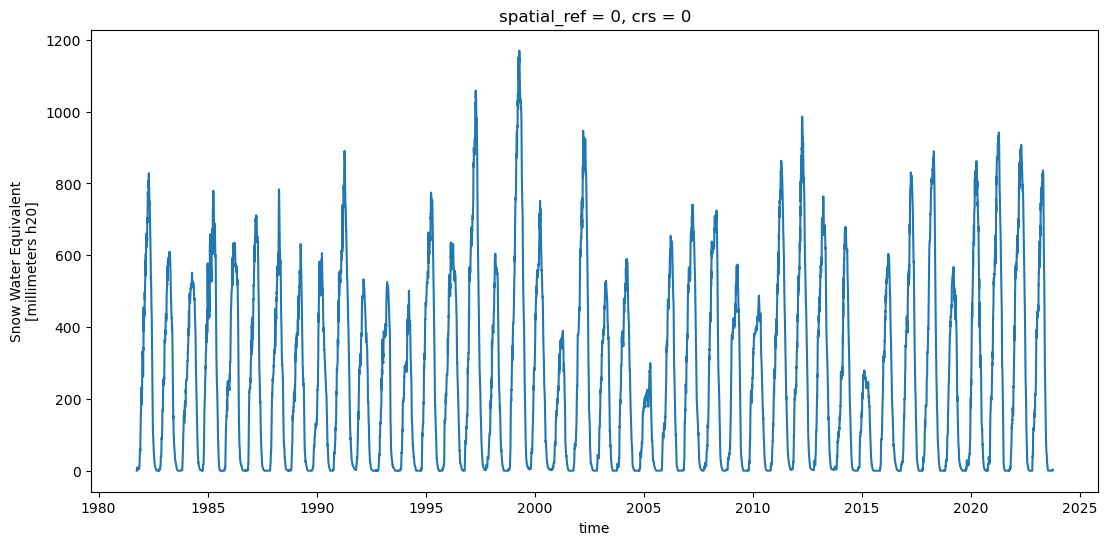

In [4]:
# plot mean
ua_skagit_clipped_mean = ua_skagit_clipped.mean(dim= ('lat', 'lon'))
ua_skagit_clipped_mean = ua_skagit_clipped_mean.assign_coords(
    year=ua_skagit_clipped_mean.time.dt.year)

plt.figure(figsize=(13, 6))
ua_skagit_clipped_mean.plot()

In [5]:
# read AR data
from pandas import to_datetime
import csv

AR_data = {}
AR_dates = []

with open('../Dataset/AR_Data/48N_event_data.csv') as f:
    reader = csv.reader(f)
    lines = list(reader)
    
    for line in lines:
        date = to_datetime(line[0], format='%Y%m%d%H').normalize()
        AR_dates.append(date)
        year = date.year
        scale = int(line[5])

        if year not in AR_data:
            AR_data[year] = {}

        AR_data[year][scale] = AR_data[year].get(scale, 0) + 1

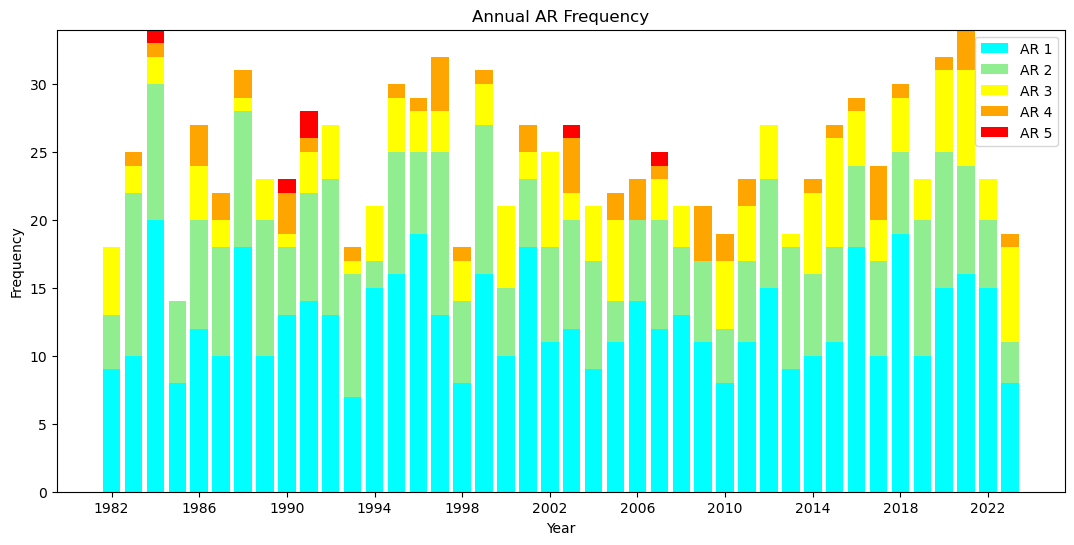

In [6]:
# plot annual frequency
years = np.array(sorted(AR_data.keys()))
# slice years to match SWE data
years = years[23:65]

ar1 = []
ar2 = []
ar3 = []
ar4 = []
ar5 = []

for year in years:
    data = AR_data[year]
    
    ar1.append(data.get(1, 0))
    ar2.append(data.get(2, 0))
    ar3.append(data.get(3, 0))
    ar4.append(data.get(4, 0))
    ar5.append(data.get(5, 0))

ar1 = np.array(ar1)
ar2 = np.array(ar2)
ar3 = np.array(ar3)
ar4 = np.array(ar4)
ar5 = np.array(ar5)

plt.figure(figsize=(13, 6))

plt.bar(years, ar1, color='cyan')
plt.bar(years, ar2, bottom=ar1, color='lightgreen')
plt.bar(years, ar3, bottom=ar1+ar2, color='yellow')
plt.bar(years, ar4, bottom=ar1+ar2+ar3, color='orange')
plt.bar(years, ar5, bottom=ar1+ar2+ar3+ar4, color='r')

plt.xlabel("Year")
plt.ylabel("Frequency")
plt.legend(["AR 1", "AR 2", "AR 3", "AR 4", "AR 5"])
plt.title("Annual AR Frequency")
plt.xticks(np.arange(years.min(), years.max() + 1, 4))
plt.show()

In [7]:
def filter_dates(scale):
    filtered_dates = []
    for date in AR_dates:
        year = date.year
        data = AR_data[year]

        freq = data.get(scale, 0)
        if freq >= 1:
            filtered_dates.append(date)

    filtered_dates = [date for date in filtered_dates if 1982 <= date.year <= 2023]

    return filtered_dates

In [8]:
def graph_AR_Events(dates, SWE_events, scale, color):
    plt.figure(figsize=(13, 6))
    ua_skagit_clipped_mean.plot(label='SWANN 4km')
    
    plt.scatter(dates, SWE_events, facecolors='none', edgecolors=color, s=50, label=f"AR Events (scale {scale})")
    
    plt.legend()
    plt.xlabel("Years")
    plt.title("Skagit Basin")
    plt.show()

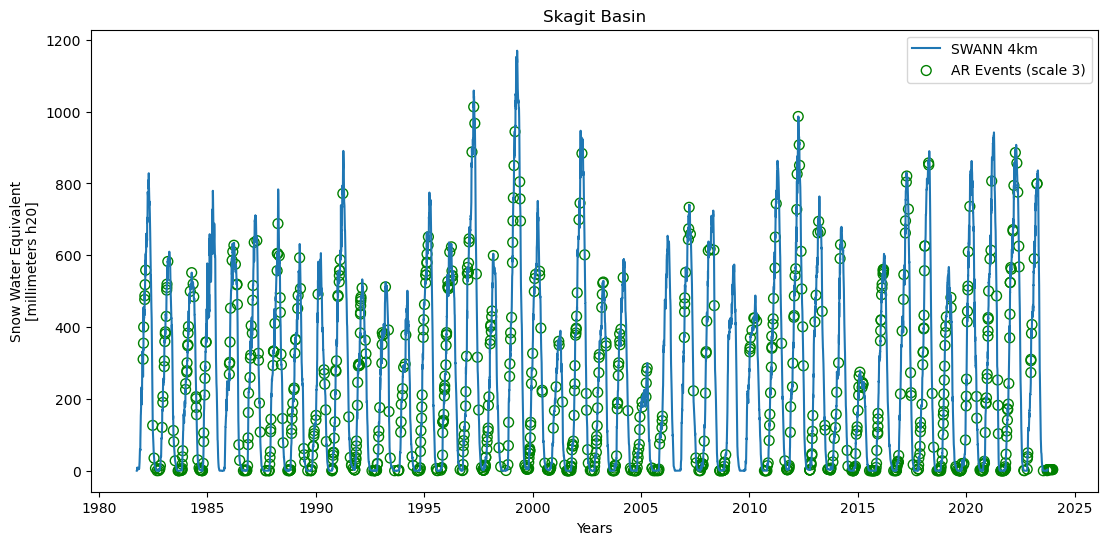

In [17]:
dates_3 = filter_dates(3)
SWE_events_3 = ua_skagit_clipped_mean.sel(time=dates_3, method='nearest')
graph_AR_Events(dates_3, SWE_events_3, 3, 'green')

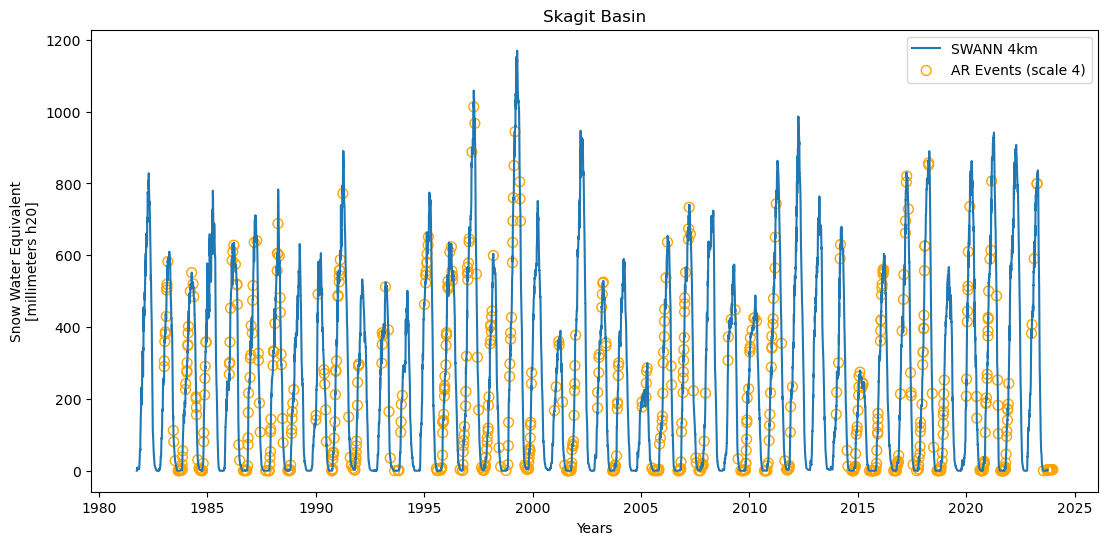

In [10]:
dates_4 = filter_dates(4)
SWE_events_4 = ua_skagit_clipped_mean.sel(time=dates_4, method='nearest')
graph_AR_Events(dates_4, SWE_events_4, 4, 'orange')

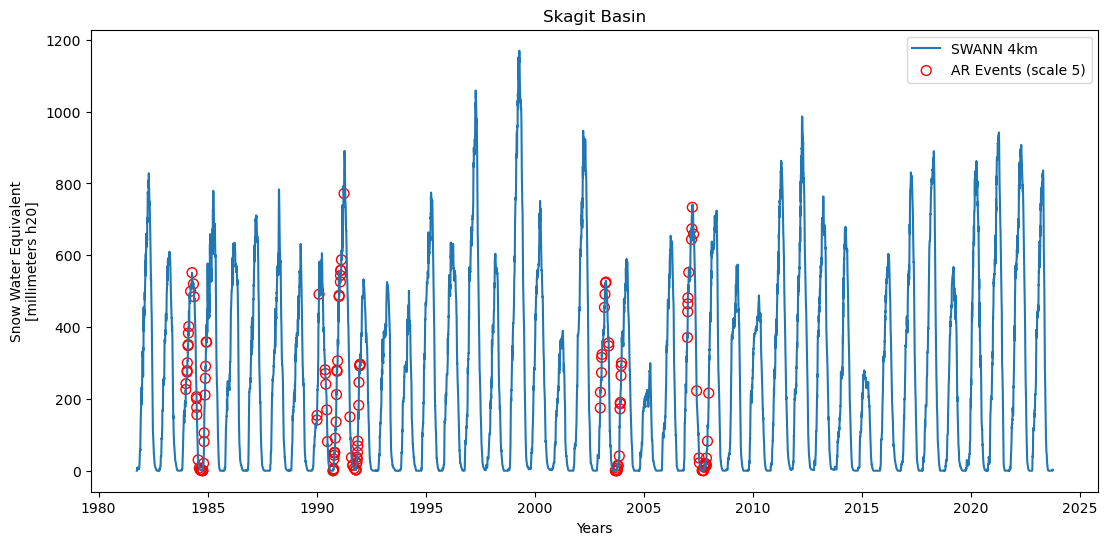

In [12]:
dates_5 = filter_dates(5)
SWE_events_5 = ua_skagit_clipped_mean.sel(time=dates_5, method='nearest')
graph_AR_Events(dates_5, SWE_events_5, 5, 'red')

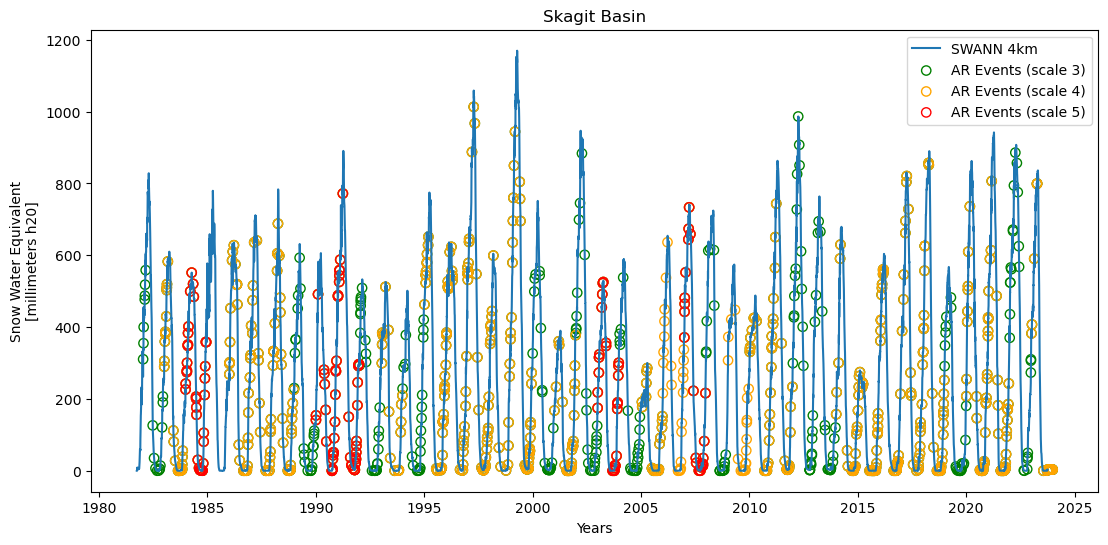

In [19]:
plt.figure(figsize=(13, 6))
ua_skagit_clipped_mean.plot(label='SWANN 4km')

plt.scatter(dates_3, SWE_events_3, facecolors='none', edgecolors='green', s=45, label="AR Events (scale 3)")
plt.scatter(dates_4, SWE_events_4, facecolors='none', edgecolors='orange', s=45, label="AR Events (scale 4)")
plt.scatter(dates_5, SWE_events_5, facecolors='none', edgecolors='red', s=45, label="AR Events (scale 5)")

plt.legend()
plt.xlabel("Years")
plt.title("Skagit Basin")
plt.show()